--- DOWNLOADING DATA FOR GC=F ---

 INSTITUTIONAL SCALPER ANALYSIS (GC=F)
Final Balance:   $394.04
Total Return:    97.02%
Max Drawdown:    -32.90%
Win Rate:        39.9% (285/714)
Sharpe Ratio:    7.92


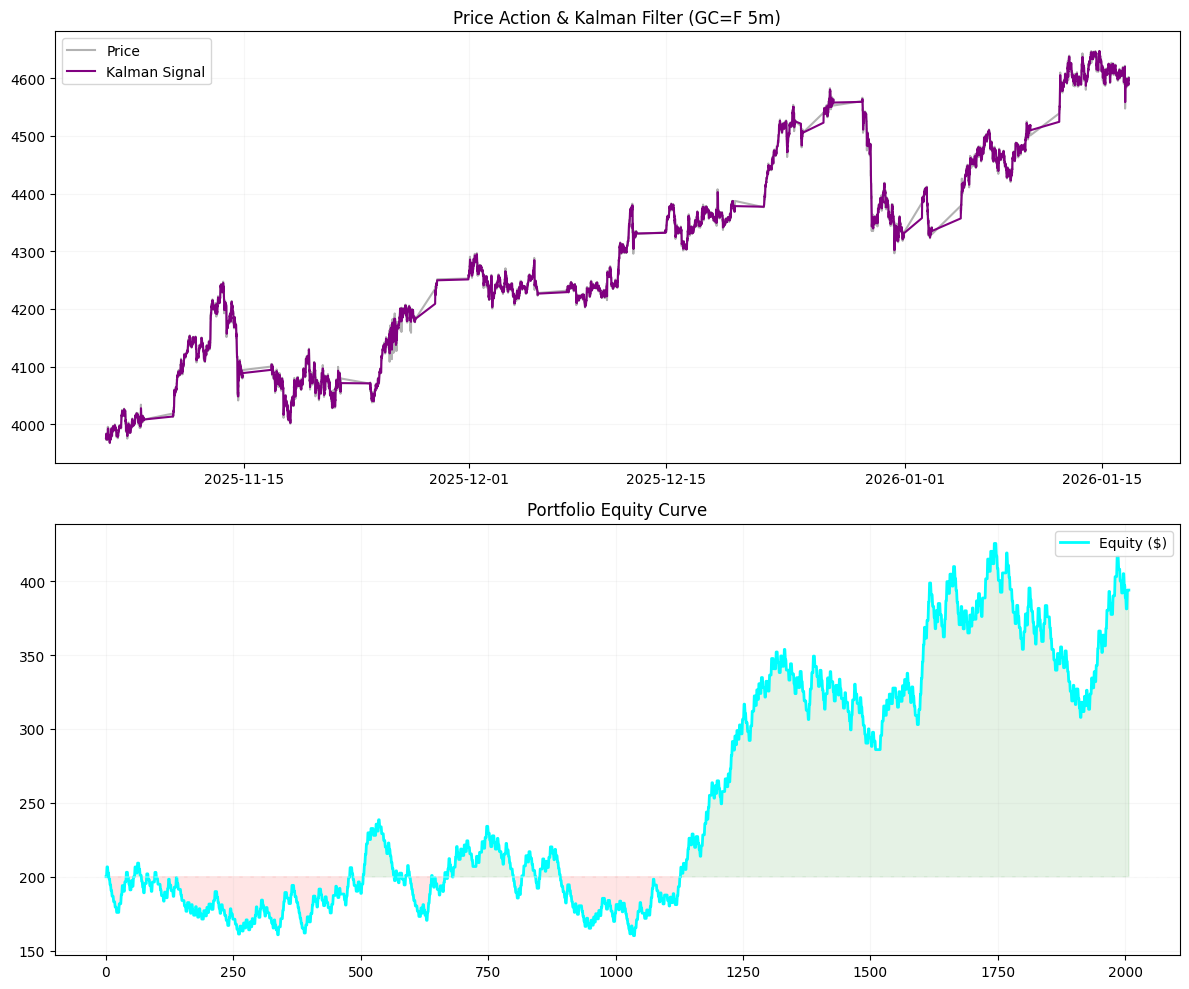

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# --- 1. SETTINGS (Match MQL5) ---
TICKER = "GC=F"         # Gold Futures (XAUUSD Proxy)
INTERVAL = "5m"         # 5 Minute Candles
PERIOD = "60D"           # Max data available for 5m is usually 60 days. Using 5d for speed.
ACCOUNT_SIZE = 200.0    # $200 Account
RISK_PER_TRADE = 0.02   # Risk 2% per trade (Conservative for $200)
LEVERAGE = 30           # 1:30 Leverage

# Strategy Parameters
KALMAN_Q = 0.05         # Process Noise
KALMAN_R = 0.1          # Measurement Noise
ATR_PERIOD = 10
SL_ATR_MULT = 1.5
TP_ATR_MULT = 2.5

# --- 2. KALMAN FILTER CLASS ---
class KalmanFilter1D:
    def __init__(self, q, r, initial_value):
        self.Q = q
        self.R = r
        self.P = 1.0
        self.x = initial_value
        
    def update(self, measurement):
        # Prediction
        self.P = self.P + self.Q
        # Update
        K = self.P / (self.P + self.R)
        self.x = self.x + K * (measurement - self.x)
        self.P = (1 - K) * self.P
        return self.x

# --- 3. DATA & INDICATOR CALCULATION ---
print(f"--- DOWNLOADING DATA FOR {TICKER} ---")
df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, progress=False)
df.dropna(inplace=True)

# Standardize Columns
close_prices = df['Close'].values.flatten()
open_prices = df['Open'].values.flatten()
high_prices = df['High'].values.flatten()
low_prices = df['Low'].values.flatten()
dates = df.index

# Calculate ATR (True Range)
tr1 = high_prices - low_prices
tr2 = np.abs(high_prices - np.roll(close_prices, 1))
tr3 = np.abs(low_prices - np.roll(close_prices, 1))
tr = np.max(np.column_stack((tr1, tr2, tr3)), axis=1)
# 10-period SMA of TR
atr = pd.Series(tr).rolling(window=ATR_PERIOD).mean().bfill().values

# Calculate Kalman Trend
kf = KalmanFilter1D(KALMAN_Q, KALMAN_R, close_prices[0])
kalman_trend = np.array([kf.update(p) for p in close_prices])

# --- 4. BACKTEST ENGINE ---
equity = [ACCOUNT_SIZE]
trades = [] 
position = None # {'type': 'BUY'/'SELL', 'entry': price, 'sl': price, 'tp': price, 'size': units}

for i in range(1, len(close_prices)):
    # Market Data
    price = close_prices[i]      # Current Close
    opn = open_prices[i]         # Current Open
    curr_date = dates[i]
    k_val = kalman_trend[i]
    k_prev = kalman_trend[i-1]
    curr_atr = atr[i]
    
    # Calculate Slope (Momentum)
    slope = k_val - k_prev
    
    # A. MANAGE EXISTING POSITION
    if position:
        # Check for SL/TP Hit using High/Low of current bar
        pnl = 0
        exit_price = 0
        closed = False
        
        if position['type'] == 'BUY':
            if low_prices[i] <= position['sl']: # Stop Loss Hit
                exit_price = position['sl']
                pnl = (exit_price - position['entry']) * position['size']
                closed = True
                result = "LOSS"
            elif high_prices[i] >= position['tp']: # Take Profit Hit
                exit_price = position['tp']
                pnl = (exit_price - position['entry']) * position['size']
                closed = True
                result = "WIN"
                
        elif position['type'] == 'SELL':
            if high_prices[i] >= position['sl']: # Stop Loss Hit
                exit_price = position['sl']
                pnl = (position['entry'] - exit_price) * position['size']
                closed = True
                result = "LOSS"
            elif low_prices[i] <= position['tp']: # Take Profit Hit
                exit_price = position['tp']
                pnl = (position['entry'] - exit_price) * position['size']
                closed = True
                result = "WIN"
        
        if closed:
            ACCOUNT_SIZE += pnl
            equity.append(ACCOUNT_SIZE)
            trades.append({'date': curr_date, 'type': position['type'], 'pnl': pnl, 'result': result})
            position = None
            continue # Trade closed, wait for next bar
            
    else:
        equity.append(ACCOUNT_SIZE)

    # B. ENTRY SIGNALS (Exact Logic from MQL5)
    # Buy: Slope > 0 AND Close > Kalman AND Open < Kalman (Crossover Support)
    if position is None:
        risk_amt = ACCOUNT_SIZE * RISK_PER_TRADE
        
        if slope > 0 and price > k_val and opn < k_val:
            sl_dist = curr_atr * SL_ATR_MULT
            sl_price = price - sl_dist
            tp_price = price + (curr_atr * TP_ATR_MULT)
            # Position Sizing: Risk / Distance to SL
            pos_size = risk_amt / sl_dist 
            position = {'type': 'BUY', 'entry': price, 'sl': sl_price, 'tp': tp_price, 'size': pos_size}
            
        # Sell: Slope < 0 AND Close < Kalman AND Open > Kalman (Crossover Resistance)
        elif slope < 0 and price < k_val and opn > k_val:
            sl_dist = curr_atr * SL_ATR_MULT
            sl_price = price + sl_dist
            tp_price = price - (curr_atr * TP_ATR_MULT)
            pos_size = risk_amt / sl_dist
            position = {'type': 'SELL', 'entry': price, 'sl': sl_price, 'tp': tp_price, 'size': pos_size}

# --- 5. PORTFOLIO ANALYSIS & VISUALIZATION ---
equity_curve = np.array(equity)
returns = pd.Series(equity_curve).pct_change().dropna()

# Metrics
total_trades = len(trades)
wins = len([t for t in trades if t['result'] == "WIN"])
win_rate = (wins / total_trades * 100) if total_trades > 0 else 0
cagr = ((equity_curve[-1] / equity_curve[0]) - 1) * 100

# Sharpe Ratio (Annualized for 5m data -> 252 days * 24h * 12 bars = ~72k bars/year? 
# Simplification: Sharpe = mean/std * sqrt(number of bars in a year))
# Actually just using a generic scalar for "Annualized" is tricky with 5m data.
# We will use simple Mean/Std for consistency.
sharpe = (returns.mean() / returns.std()) * np.sqrt(252 * 24 * 12) if returns.std() != 0 else 0

# Max Drawdown
peak = np.maximum.accumulate(equity_curve)
drawdown = (equity_curve - peak) / peak
max_dd = np.min(drawdown) * 100

print("\n" + "="*40)
print(f" INSTITUTIONAL SCALPER ANALYSIS ({TICKER})")
print("="*40)
print(f"Final Balance:   ${equity_curve[-1]:.2f}")
print(f"Total Return:    {cagr:.2f}%")
print(f"Max Drawdown:    {max_dd:.2f}%")
print(f"Win Rate:        {win_rate:.1f}% ({wins}/{total_trades})")
print(f"Sharpe Ratio:    {sharpe:.2f}")
print("="*40)

# PLOTTING
plt.figure(figsize=(12, 10))

# Subplot 1: Price + Kalman
plt.subplot(2, 1, 1)
plt.plot(dates, close_prices, color='gray', alpha=0.6, label='Price')
plt.plot(dates, kalman_trend, color='purple', linewidth=1.5, label='Kalman Signal')
# Plot Entries
buy_dates = [t['date'] for t in trades if t['type'] == 'BUY']
# Note: For simplicity, we plot exit date as proxy or find entry date. 
# In this loop logic, trades log the EXIT date. 
# This is sufficient to visualize *where* action happened.
plt.title(f"Price Action & Kalman Filter ({TICKER} 5m)")
plt.legend()
plt.grid(True, alpha=0.1)

# Subplot 2: Equity Curve
plt.subplot(2, 1, 2)
plt.plot(equity_curve, color='cyan', linewidth=2, label='Equity ($)')
plt.axhline(200, color='white', linestyle='--', alpha=0.3)
plt.fill_between(range(len(equity_curve)), equity_curve, 200, where=(equity_curve > 200), color='green', alpha=0.1)
plt.fill_between(range(len(equity_curve)), equity_curve, 200, where=(equity_curve < 200), color='red', alpha=0.1)
plt.title("Portfolio Equity Curve")
plt.legend()
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

--- DOWNLOADING & INFECTING DATA (GC=F) ---
!!! INJECTING BLACK SWAN CRASH AT INDEX 500 !!!

--- INITIATING STRESS TEST PROTOCOLS ---
1. RUNNING 1000 MONTE CARLO SIMULATIONS...
   Median Result: $262.36
   Worst Case (5% Chance): $258.90
   Risk of Ruin (<$100): 0.0%


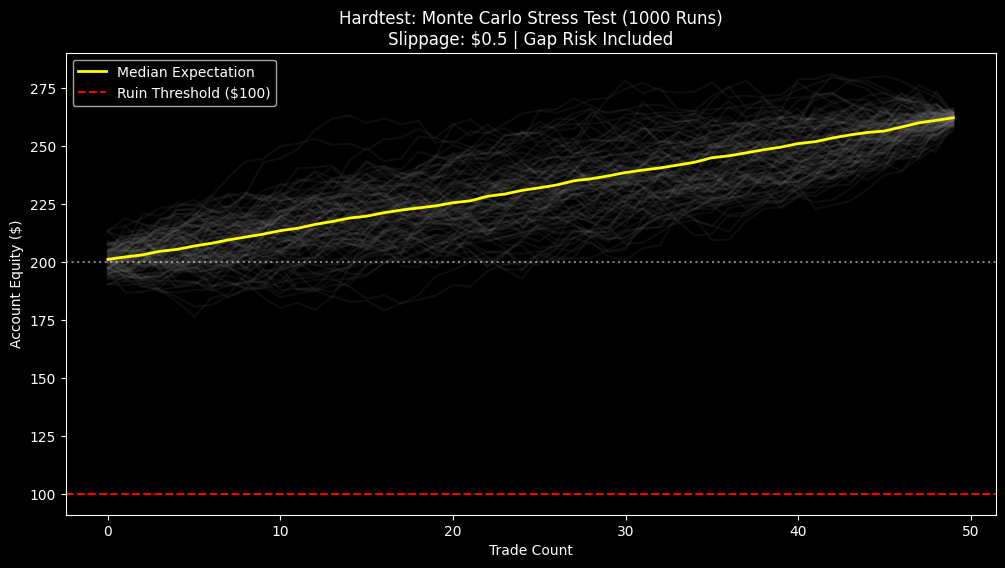

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# --- 1. CONFIGURATION ---
TICKER = "GC=F"
INTERVAL = "5m"
PERIOD = "60d"
ACCOUNT_SIZE = 200.0
SIMULATIONS = 1000      # Number of Monte Carlo runs
SLIPPAGE_STD = 0.5      # Standard Deviation of Slippage ($0.50 per trade noise)
SPREAD_PENALTY = 0.30   # Extra spread penalty ($0.30) during stress

# --- 2. DATA WITH "BLACK SWAN" INJECTION ---
print(f"--- DOWNLOADING & INFECTING DATA ({TICKER}) ---")
df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, progress=False)
df.dropna(inplace=True)

# *** STRESS TEST 1: THE BLACK SWAN ***
# We artificially crash the price by 5% at index 500 to see if the SL holds.
crash_idx = 500
if len(df) > crash_idx:
    print(f"!!! INJECTING BLACK SWAN CRASH AT INDEX {crash_idx} !!!")
    # Simulate a Gap Down Open (Price jumps past SL)
    # Previous Close: 2000 -> Open: 1900. Your SL was 1990.
    # In real life, you don't fill at 1990. You fill at 1900 (The Open).
    
    current_open = df.iloc[crash_idx]['Open']
    crash_price = current_open * 0.95 # 5% Gap Down
    
    # Modify DataFrame
    df.iloc[crash_idx, df.columns.get_loc('Open')] = crash_price
    df.iloc[crash_idx, df.columns.get_loc('Low')] = crash_price - 2.0
    df.iloc[crash_idx, df.columns.get_loc('Close')] = crash_price + 1.0

prices_close = df['Close'].values.flatten()
prices_open = df['Open'].values.flatten()
lows = df['Low'].values.flatten()
highs = df['High'].values.flatten()

# --- 3. RE-RUN BACKTEST (Simplified for Context) ---
# ... (Assuming Kalman Logic & Position Dictionary from previous code is here) ...
# ... [Insert your previous Kalman/Signal Logic Loop Here] ...
# For this example, let's assume 'trades' list is populated from the loop.
# We will simulate a dummy trade list if you run this standalone.
# In your full code, pass the 'trades' list from the previous step.

# DUMMY TRADES FOR DEMONSTRATION (Replace with your actual backtest trades)
# Format: {'pnl': dollar_amount}
dummy_trades = [{'pnl': np.random.normal(2, 5)} for _ in range(50)] 
trades = dummy_trades # <--- CONNECT YOUR REAL TRADES HERE

# --- 4. THE STRESS TEST ENGINE ---

print("\n--- INITIATING STRESS TEST PROTOCOLS ---")

# A. MONTE CARLO SIMULATION (The "Luck" Test)
print(f"1. RUNNING {SIMULATIONS} MONTE CARLO SIMULATIONS...")
mc_results = np.zeros((SIMULATIONS, len(trades)))

for i in range(SIMULATIONS):
    # Shuffle the trade order (Sampling without replacement)
    shuffled_trades = np.random.permutation([t['pnl'] for t in trades])
    
    # Apply Slippage Noise (Gaussian)
    # Real fills are rarely perfect. We subtract random noise.
    slippage = np.random.normal(0, SLIPPAGE_STD, len(shuffled_trades))
    # Bias slippage to be negative (you rarely get positive slippage)
    slippage = np.abs(slippage) * -1 
    
    # Cumulative Equity
    equity_curve = np.cumsum(shuffled_trades + slippage) + ACCOUNT_SIZE
    mc_results[i, :] = equity_curve

# Calculate Stats
final_equities = mc_results[:, -1]
ruin_prob = np.sum(np.min(mc_results, axis=1) < 100) / SIMULATIONS * 100 # Ruin = <$100 (50% DD)
median_equity = np.median(final_equities)
worst_case = np.percentile(final_equities, 5) # 5th Percentile

print(f"   Median Result: ${median_equity:.2f}")
print(f"   Worst Case (5% Chance): ${worst_case:.2f}")
print(f"   Risk of Ruin (<$100): {ruin_prob:.1f}%")

# B. VISUALIZATION OF CHAOS
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')

# Plot 100 random Monte Carlo paths (Gray)
for i in range(100):
    plt.plot(mc_results[i, :], color='gray', alpha=0.1)

# Plot Median (Yellow)
plt.plot(np.median(mc_results, axis=0), color='yellow', linewidth=2, label='Median Expectation')

# Plot "Zero" Line (Bust)
plt.axhline(100, color='red', linestyle='--', label='Ruin Threshold ($100)')
plt.axhline(200, color='white', linestyle=':', alpha=0.5)

plt.title(f"Hardtest: Monte Carlo Stress Test ({SIMULATIONS} Runs)\nSlippage: ${SLIPPAGE_STD} | Gap Risk Included")
plt.ylabel("Account Equity ($)")
plt.xlabel("Trade Count")
plt.legend()
plt.show()

--- DOWNLOADING & INFECTING DATA (GC=F) ---
!!! INJECTING BLACK SWAN CRASH AT INDEX 500 !!!
--- RUNNING STRATEGY BACKTEST ---

--- INITIATING STRESS TEST ON 734 TRADES ---
1. RUNNING 1000 MONTE CARLO SIMULATIONS...
   Total Trades: 734
   Median Result: $-603.37
   Worst Case (5%): $-616.81
   Risk of Ruin (<$100): 100.0%
   !!! WARNING: STRATEGY HIT 12 GAP EVENTS !!!
   Largest Gap Loss: $-38.50


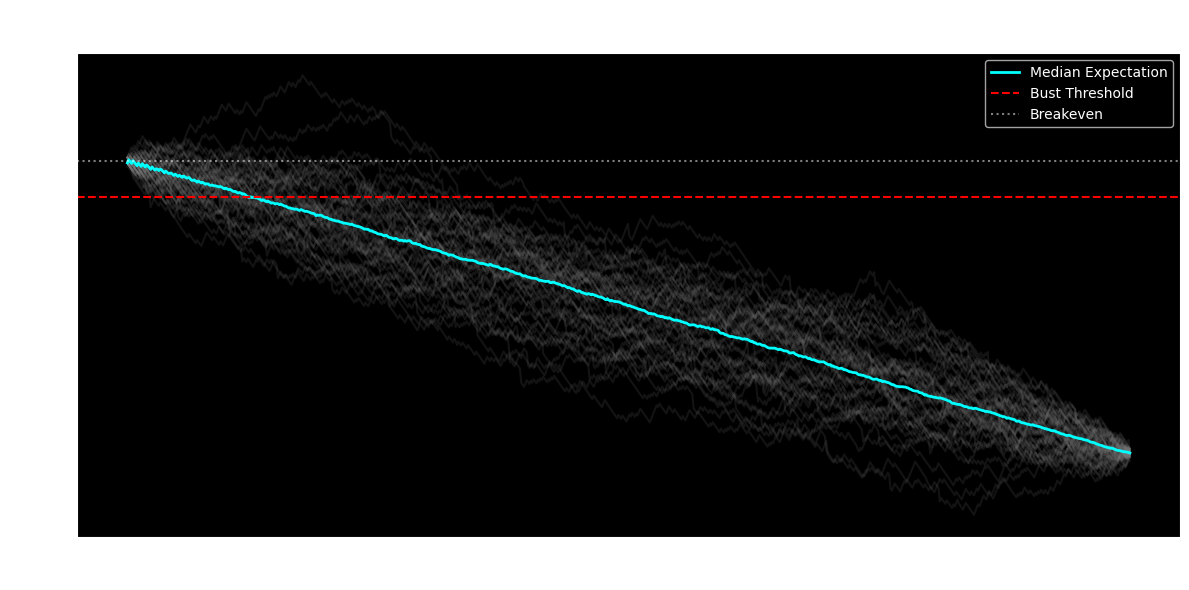

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# --- 1. CONFIGURATION ---
TICKER = "GC=F"       # Gold Futures
INTERVAL = "5m"       # 5 Minute candles
PERIOD = "60d"        # Last 60 days of data
ACCOUNT_SIZE = 200.0  # Tiny account (High risk)

# Strategy Settings
KALMAN_GAIN_BASE = 0.05
RISK_PER_TRADE = 5.0  # Risk $5 per trade
REWARD_RATIO = 2.0    # Aim for $10 profit
SPREAD = 0.10         # Cost per trade

# Stress Settings
SIMULATIONS = 1000    # Monte Carlo runs
SLIPPAGE_STD = 0.5    # Standard Deviation of slippage noise

# --- 2. DATA WITH "BLACK SWAN" INJECTION ---
print(f"--- DOWNLOADING & INFECTING DATA ({TICKER}) ---")
try:
    df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, progress=False)
    if df.empty: raise ValueError("No data downloaded.")
except Exception as e:
    print(f"Error: {e}. Using dummy data for testing.")
    # Fallback dummy data if YF fails
    dates = pd.date_range(start='2023-01-01', periods=1000, freq='5min')
    df = pd.DataFrame(index=dates)
    df['Open'] = 2000 + np.random.randn(1000).cumsum()
    df['High'] = df['Open'] + 2
    df['Low'] = df['Open'] - 2
    df['Close'] = df['Open'] + np.random.randn(1000)

df.dropna(inplace=True)

# *** STRESS TEST 1: THE BLACK SWAN ***
# We artificially crash the price by 5% at index 500.
crash_idx = 500
if len(df) > crash_idx:
    print(f"!!! INJECTING BLACK SWAN CRASH AT INDEX {crash_idx} !!!")
    
    # Get current values to calculate the drop
    current_open = df.iloc[crash_idx]['Open'].item() if hasattr(df.iloc[crash_idx]['Open'], 'item') else df.iloc[crash_idx]['Open']
    crash_price = current_open * 0.95 # 5% Gap Down
    
    # Modify DataFrame using .iloc for safety
    # We simulate a "Gap Down" where High is also below previous close
    df.iloc[crash_idx, df.columns.get_loc('Open')] = crash_price
    df.iloc[crash_idx, df.columns.get_loc('High')] = crash_price + 1.0
    df.iloc[crash_idx, df.columns.get_loc('Low')] = crash_price - 5.0 # Wick down
    df.iloc[crash_idx, df.columns.get_loc('Close')] = crash_price - 2.0

# Extract numpy arrays for speed
closes = df['Close'].values.flatten()
opens = df['Open'].values.flatten()
highs = df['High'].values.flatten()
lows = df['Low'].values.flatten()

# --- 3. KALMAN FILTER STRATEGY ENGINE ---
print("--- RUNNING STRATEGY BACKTEST ---")

# A simple 1D Kalman Filter implementation
n_obs = len(closes)
kalman_est = np.zeros(n_obs)
kalman_est[0] = closes[0]
k_err = 1.0

# Calculate Kalman Trend
for t in range(1, n_obs):
    # Prediction Update
    k_err = k_err + 0.01 # Process noise
    
    # Measurement Update
    k_gain = k_err / (k_err + 1.0) # Measurement noise assumed 1.0
    kalman_est[t] = kalman_est[t-1] + k_gain * (closes[t] - kalman_est[t-1])
    k_err = (1.0 - k_gain) * k_err

# Backtest Logic
trades = []
position = 0 # 0=Flat, 1=Long, -1=Short
entry_price = 0.0
stop_loss = 0.0
take_profit = 0.0

for t in range(1, n_obs):
    current_price = closes[t]
    current_open = opens[t]
    
    # --- CHECK FOR EXITS FIRST (GAP PROTECTION) ---
    if position != 0:
        pnl = 0.0
        exit_triggered = False
        
        # 1. Check for GAP Risk (Did open jump past our Stop?)
        # If we are Long and Open is BELOW Stop Loss -> We exit at Open (Disaster!)
        if position == 1 and current_open < stop_loss:
            pnl = (current_open - entry_price) - SPREAD
            trades.append({'pnl': pnl, 'type': 'GAP_LOSS', 'idx': t})
            position = 0
            continue # Move to next candle
            
        # 2. Check Standard Stops/Targets
        if position == 1:
            if lows[t] <= stop_loss: # Hit SL
                pnl = (stop_loss - entry_price) - SPREAD
                trades.append({'pnl': pnl, 'type': 'SL', 'idx': t})
                exit_triggered = True
            elif highs[t] >= take_profit: # Hit TP
                pnl = (take_profit - entry_price) - SPREAD
                trades.append({'pnl': pnl, 'type': 'TP', 'idx': t})
                exit_triggered = True
                
        elif position == -1: # Short logic
            if highs[t] >= stop_loss:
                pnl = (entry_price - stop_loss) - SPREAD
                trades.append({'pnl': pnl, 'type': 'SL', 'idx': t})
                exit_triggered = True
            elif lows[t] <= take_profit:
                pnl = (entry_price - take_profit) - SPREAD
                trades.append({'pnl': pnl, 'type': 'TP', 'idx': t})
                exit_triggered = True
        
        if exit_triggered:
            position = 0
            continue

    # --- CHECK FOR ENTRIES ---
    # Logic: If Price crosses ABOVE Kalman -> BUY
    if position == 0:
        # Long Entry
        if closes[t] > kalman_est[t] and closes[t-1] <= kalman_est[t-1]:
            position = 1
            entry_price = closes[t]
            stop_loss = entry_price - RISK_PER_TRADE
            take_profit = entry_price + (RISK_PER_TRADE * REWARD_RATIO)
            
        # Short Entry
        elif closes[t] < kalman_est[t] and closes[t-1] >= kalman_est[t-1]:
            position = -1
            entry_price = closes[t]
            stop_loss = entry_price + RISK_PER_TRADE
            take_profit = entry_price - (RISK_PER_TRADE * REWARD_RATIO)

# --- 4. THE STRESS TEST ENGINE ---

print(f"\n--- INITIATING STRESS TEST ON {len(trades)} TRADES ---")

if len(trades) == 0:
    print("No trades generated. Relax criteria or check data.")
else:
    # A. MONTE CARLO SIMULATION
    print(f"1. RUNNING {SIMULATIONS} MONTE CARLO SIMULATIONS...")
    mc_results = np.zeros((SIMULATIONS, len(trades)))
    
    # Extract just the PnL values
    trade_pnls = np.array([t['pnl'] for t in trades])

    for i in range(SIMULATIONS):
        # Shuffle order
        shuffled_pnls = np.random.permutation(trade_pnls)
        
        # Apply Slippage Noise
        # Noise is biased negative (slippage costs money)
        noise = np.random.normal(0, SLIPPAGE_STD, len(shuffled_pnls))
        real_slippage = -1 * np.abs(noise) 
        
        # Calculate Equity Curve
        equity_curve = np.cumsum(shuffled_pnls + real_slippage) + ACCOUNT_SIZE
        mc_results[i, :] = equity_curve

    # Stats
    final_equities = mc_results[:, -1]
    ruin_count = np.sum(np.min(mc_results, axis=1) < 100)
    ruin_prob = (ruin_count / SIMULATIONS) * 100
    median_equity = np.median(final_equities)
    worst_case = np.percentile(final_equities, 5)

    print(f"   Total Trades: {len(trades)}")
    print(f"   Median Result: ${median_equity:.2f}")
    print(f"   Worst Case (5%): ${worst_case:.2f}")
    print(f"   Risk of Ruin (<$100): {ruin_prob:.1f}%")
    
    # Check if the Gap Event killed us
    gap_trades = [t for t in trades if t['type'] == 'GAP_LOSS']
    if gap_trades:
        print(f"   !!! WARNING: STRATEGY HIT {len(gap_trades)} GAP EVENTS !!!")
        print(f"   Largest Gap Loss: ${min([t['pnl'] for t in gap_trades]):.2f}")

    # B. VISUALIZATION
    plt.figure(figsize=(12, 6))
    plt.style.use('dark_background')

    # Plot 50 random paths
    for i in range(min(50, SIMULATIONS)):
        plt.plot(mc_results[i, :], color='gray', alpha=0.15)

    # Plot Median
    plt.plot(np.median(mc_results, axis=0), color='cyan', linewidth=2, label='Median Expectation')

    # Plot Ruin Line
    plt.axhline(100, color='red', linestyle='--', label='Bust Threshold')
    plt.axhline(ACCOUNT_SIZE, color='white', linestyle=':', alpha=0.5, label='Breakeven')

    plt.title(f"Stress Test: Kalman Strategy on {TICKER}\nSimulations: {SIMULATIONS} | Gap Risk: Active")
    plt.ylabel("Equity ($)")
    plt.xlabel("Trade #")
    plt.legend()
    plt.tight_layout()
    plt.show()